# Models creation

In [61]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# getting the data ready

performance = pd.read_csv('Gaming_Academic_Performance.csv').drop('student_id', axis = 1)
performance = performance[performance['grades'].between(0, 100)]

X = performance.drop('grades', axis = 1)
X = pd.get_dummies(X)

y = performance['grades']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## RandomForestRegressor


### Fitting

In [62]:
# fitting

reg = RandomForestRegressor()

reg.fit(X_train, y_train)

y_pred_reg = reg.predict(X_test)

### Evaluation

In [63]:
# evaluation
eval_reg = print(f'r2: {reg.score(X_test, y_test)}\n',
      f'mae: {mean_absolute_error(y_test, y_pred_reg)}\n',
      f'mse: {mean_squared_error(y_test, y_pred_reg)}\n')

scores = cross_val_score(reg, X, y, cv=5, scoring='r2')
scores.std()


r2: 0.9227237278348802
 mae: 4.734954633752081
 mse: 35.94089808221223



np.float64(0.0027039774352493034)

### Checking on overfitting

In [64]:
# checking on overfitting
print(reg.score(X_train, y_train), reg.score(X_test, y_test))

0.9902128871554915 0.9227237278348802


### Plotting

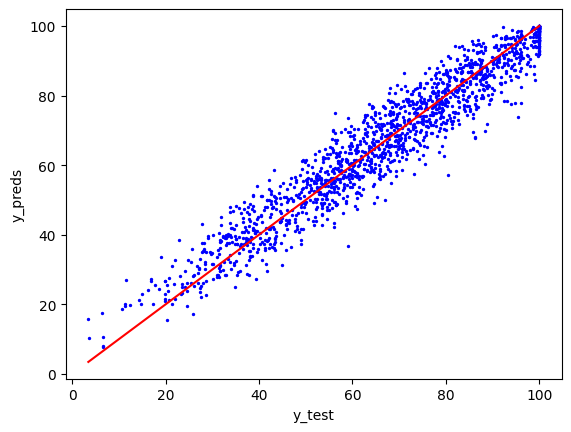

In [65]:
# plotting
plt.figure()
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel('y_test')
plt.ylabel('y_preds')
plt.scatter(y_test, y_pred_reg, c = 'b', s = 2)

plt.show()

### Top 5 model features

<Axes: title={'center': 'feature importance'}>

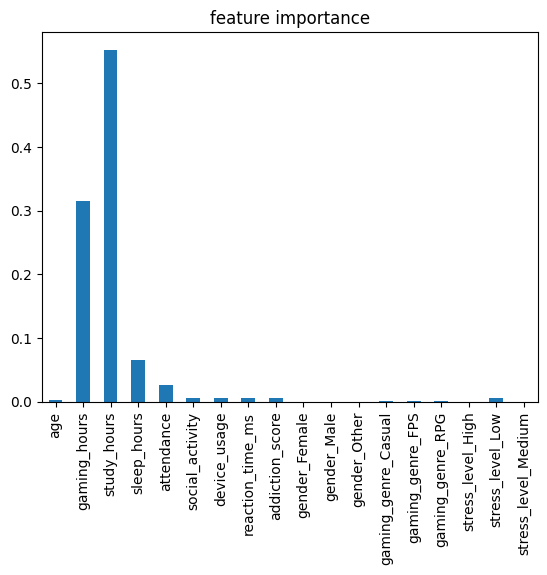

In [66]:
feature_dict = dict(zip(X.columns, reg.feature_importances_))

feature_X = pd.DataFrame(feature_dict, index = [0])
feature_X.T.plot.bar(title = 'feature importance', legend = False)

In [109]:
# top 5 model features
top_5_model_features = X.columns[reg.feature_importances_.argsort()[-5:][::-1]]
print('top 5 model features: ', top_5_model_features)

top 5 model features:  Index(['study_hours', 'gaming_hours', 'sleep_hours', 'attendance',
       'stress_level_Low'],
      dtype='object')


## GradientBoostingRegressor




### Fitting

In [ ]:
gbr = GradientBoostingRegressor()


# fitting
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

### Evaluation

In [ ]:
# evaluation

eval_gbr = print(f'r2: {gbr.score(X_test, y_test)}\n',
      f'mae: {mean_absolute_error(y_test, y_pred_gbr)}\n',
      f'mse: {mean_squared_error(y_test, y_pred_gbr)}\n')

scores = cross_val_score(gbr, X, y, cv=5, scoring='r2')
scores.std()


r2: 0.9286484072487101
 mae: 4.571118427286819
 mse: 33.18535238860987



np.float64(0.0024375863073555337)

### Checking on overfitting

In [ ]:
# checking on overfitting
print(gbr.score(X_train, y_train), gbr.score(X_test, y_test))

0.9454885920266652 0.9286484072487101


### Top 5 model features

<Axes: title={'center': 'feature importance'}>

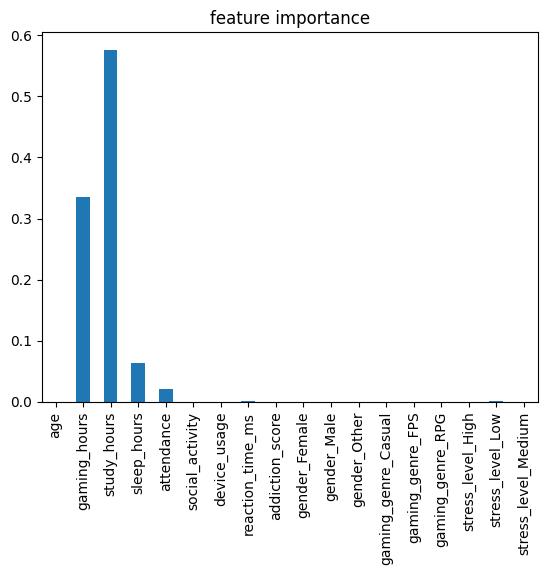

In [ ]:
# top 5 model features
feature_dict = dict(zip(X.columns, gbr.feature_importances_))

feature_X = pd.DataFrame(feature_dict, index = [0])
feature_X.T.plot.bar(title = 'feature importance', legend = False)

## Comparison of 2 graphs



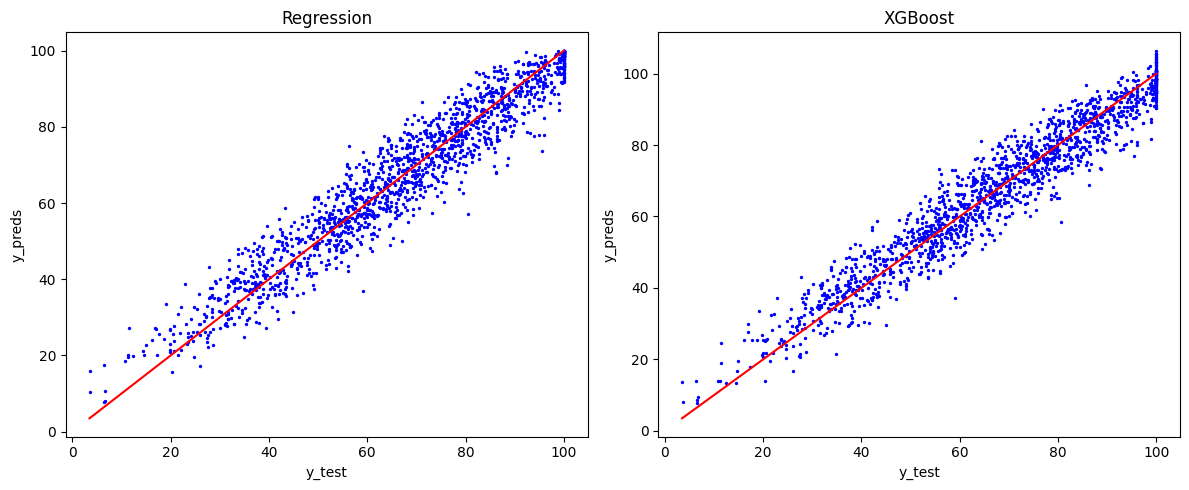

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regression
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red')
axes[0].scatter(y_test, y_pred_reg, c='b', s=2)
axes[0].set_xlabel('y_test')
axes[0].set_ylabel('y_preds')
axes[0].set_title('Regression')

# XGBoost
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red')
axes[1].scatter(y_test, y_pred_gbr, c='b', s=2)
axes[1].set_xlabel('y_test')
axes[1].set_ylabel('y_preds')
axes[1].set_title('XGBoost')

plt.tight_layout()
plt.show()

# Generating predictions

In [ ]:
# generating predictions

model = input('select model (RandomForestRegressor/GradientBoostingRegressor): ')
if model == 'reg':
  model = reg
elif model == 'gbr':
  model = gbr
else:
  print('error')

print("your data:\n")

# input data
study_hours = float(input("study_hours: "))
gaming_hours = float(input("gaming_hours (per day): "))
sleep_hours = float(input("sleep_hours: "))
attendance = float(input("attendance (%): "))

new_data = {
    "gaming_hours": gaming_hours,
    "study_hours": study_hours,
    "sleep_hours": sleep_hours,
    "attendance": attendance
}

new_data = pd.DataFrame([new_data])
new_data = pd.get_dummies(new_data)

numeric_cols = X.select_dtypes(include=np.number).columns # numeric columns
dummies_cols = [c for c in X.columns if c not in numeric_cols] # dummies columns

new_data = new_data.reindex(columns=X.columns) # reindexing
new_data[numeric_cols] = new_data[numeric_cols].fillna(X[numeric_cols].median()) # replacing missing values for numeric columns with median value
new_data[dummies_cols] = new_data[dummies_cols].fillna(0) # replacing missing values for dummies columns with 0

prediction = model.predict(new_data)

print('prediction: ', prediction)

select model (RandomForestRegressor/GradientBoostingRegressor): xgb
your data:

study_hours: 5
gaming_hours (per day): 2
sleep_hours: 7
attendance (%): 85
prediction:  [82.62730464]


# Saving models

In [ ]:
pickle.dump(gbr, open('GradientBoostingRegressor.pkl', 'wb'))
pickle.dump(reg, open('RandomForestRegressor.pkl', 'wb'))